## MNIST dataset

In [1]:
from sklearn.datasets import fetch_openml

# if as_frame=True returns Pandas's dataframe, else returns Numpy arr
mnist = fetch_openml('mnist_784', as_frame=False)

print(mnist.DESCR[:500]+"...")
print(mnist.data)
print(mnist.target)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-si...
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
['5' '0' '4' ... '4' '5' '6']


Text(0.5, 1.0, '9')

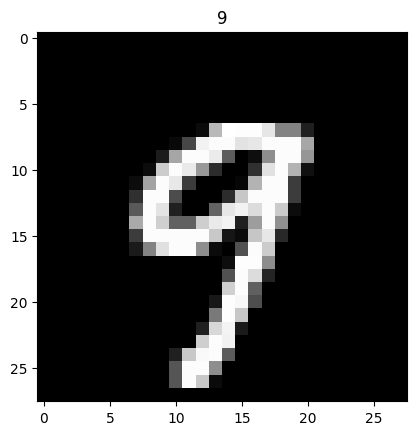

In [2]:
import matplotlib.pyplot as plt
import numpy as np

X, y = mnist.data, mnist.target
digito = X[45].reshape((28,28))
plt.imshow(digito, cmap="grey")
plt.title(y[45])


In [3]:
# Split dataset
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
y_train_5, y_test_5 = (y_train == '5'), (y_test == '5')

## Confusion Matrix

In [8]:
from sklearn.metrics import confusion_matrix # [[vn, fp], [fn, vp]]
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)
y_pred_5 = sgd_clf.predict(X_train)

dummy_clf = DummyClassifier() # la predicción es la clase con más miembros
dummy_clf.fit(X_train, y_train_5)
y_pred_5d = dummy_clf.predict(X_train)

print(confusion_matrix(y_pred_5, y_train_5))
print(confusion_matrix(y_pred_5d, y_train_5))

[[52316   601]
 [ 2263  4820]]
[[54579  5421]
 [    0     0]]


## Otras cosas

In [24]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X)
cum_sum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cum_sum >= 0.95)+1 # dimension to mantaine the 95% of the variance in the dataset
print(d)


X_red = PCA(n_components=d).fit_transform(X)
print(X_red.shape)

154
(70000, 154)


In [26]:
# o más directo
pca = PCA(n_components=0.95)
X_red2 = pca.fit_transform(X)
print(X_red2.shape)

(70000, 154)


In [27]:
X_restored = pca.inverse_transform(X_red)
print(X_restored.shape)

(70000, 784)


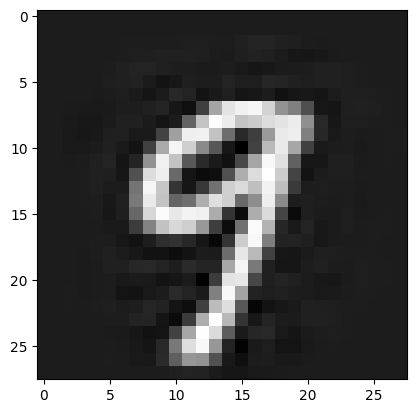

In [30]:
plt.imshow(X_restored[45].reshape(28,28), cmap="grey")

In [23]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target.astype(int)


X_train, X_test, y_train, y_test = train_test_split(X[:30000], y[:30000], test_size=20)
mlp = MLPClassifier(hidden_layer_sizes=[187, 300, 187], early_stopping=True, verbose=True)

pipeline = make_pipeline(MinMaxScaler(), mlp)
pipeline.fit(X_train, y_train)

Iteration 1, loss = 0.45748002
Validation score: 0.941961
Iteration 2, loss = 0.16669880
Validation score: 0.954303
Iteration 3, loss = 0.10553857
Validation score: 0.964643
Iteration 4, loss = 0.07604046
Validation score: 0.970314
Iteration 5, loss = 0.05632509
Validation score: 0.969313
Iteration 6, loss = 0.04456766
Validation score: 0.968312
Iteration 7, loss = 0.03316674
Validation score: 0.968312
Iteration 8, loss = 0.02245961
Validation score: 0.974316
Iteration 9, loss = 0.01584083
Validation score: 0.974316
Iteration 10, loss = 0.01578800
Validation score: 0.972648
Iteration 11, loss = 0.01100517
Validation score: 0.974983
Iteration 12, loss = 0.00972774
Validation score: 0.973983
Iteration 13, loss = 0.01079994
Validation score: 0.974316
Iteration 14, loss = 0.01353217
Validation score: 0.968646
Iteration 15, loss = 0.01092692
Validation score: 0.975984
Iteration 16, loss = 0.00862442
Validation score: 0.968646
Iteration 17, loss = 0.01686823
Validation score: 0.968312
Iterat

Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('mlpclassifier',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=[187, 300, 187],
                               verbose=True))])

In [20]:
from sklearn.metrics import root_mean_squared_error

print(mlp.best_validation_score_)
mlp.score(X_test, y_test)

0.9793195463642428


1.0

In [5]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
X_train, X_test, y_train, y_test = X[:10000], X[10000:], y[:10000], y[10000:]

In [6]:
# Ej 3-1
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

kneigh = KNeighborsClassifier(n_neighbors=4, weights="distance")
pipeline = make_pipeline(MinMaxScaler(), kneigh)
pipeline.fit(X_train, y_train)

pipeline.score(X_test, y_test)


0.95035

In [47]:
from sklearn.metrics import accuracy_score
y_pred = pipeline.predict(X_test)
accuracy_score(y_test, y_pred) # 5: 0.9688, 6: 0.9677, 

0.9714

In [7]:
# Ej 3-2
from scipy.ndimage import shift
def shift_dir(img, dir):
    return shift(img, dir)

digito = X_train[0].reshape(28,28)
digito_l = shift_dir(digito, [0,-1])
digito_r = shift_dir(digito, [0,1])
digito_d = shift_dir(digito, [1,0])
digito_u = shift_dir(digito, [-1,0])


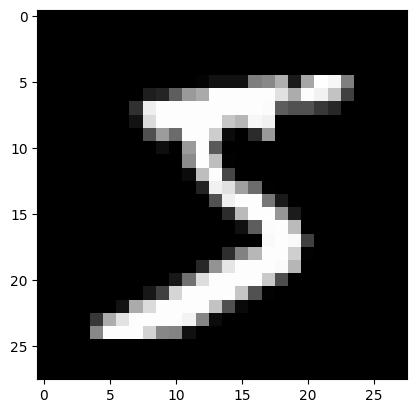

In [33]:
import matplotlib.pyplot as plt
plt.imshow(digito, cmap="grey")

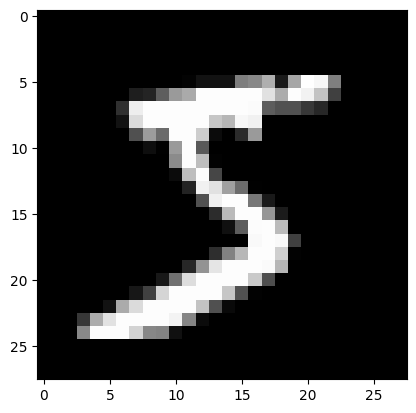

In [35]:
plt.imshow(digito_l, cmap="grey")

In [16]:
import numpy as np
X_train_exp, y_train_exp = [], []
for idx in range(X_train.shape[0]):
    X_train_exp.append(X_train[idx])
    y_train_exp.append(y_train[idx])
    dig = X_train[idx].reshape(28,28)
    X_train_exp.append(shift_dir(dig, [0,-1]).reshape(X_train[idx].shape))
    y_train_exp.append(y_train[idx])
    X_train_exp.append(shift_dir(dig, [0,1]).reshape(X_train[idx].shape))
    y_train_exp.append(y_train[idx])
    X_train_exp.append(shift_dir(dig, [-1,0]).reshape(X_train[idx].shape))
    y_train_exp.append(y_train[idx])
    X_train_exp.append(shift_dir(dig, [1,0]).reshape(X_train[idx].shape))
    y_train_exp.append(y_train[idx])

X_train_exp = np.array(X_train_exp)
y_train_exp = np.array(y_train_exp)
X_train_exp.shape

(50000, 784)

In [17]:
from sklearn.neighbors import KNeighborsClassifier

kneigh = KNeighborsClassifier(n_neighbors=4, weights="distance")
kneigh.fit(X_train_exp, y_train_exp)

kneigh.score(X_test, y_test)

0.9601666666666666